In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

In [2]:
ARTIFACTS_DIR = "artifacts"

X_test = pd.read_csv(f"{ARTIFACTS_DIR}/X_test.csv")
y_test = pd.read_csv(f"{ARTIFACTS_DIR}/y_test.csv").squeeze("columns")
feature_columns = joblib.load(f"{ARTIFACTS_DIR}/feature_columns.joblib")

# Use best model from notebook 2
model = joblib.load(f"{ARTIFACTS_DIR}/best_risk_model_pipeline.joblib")

print("Loaded test shape:", X_test.shape, y_test.shape)

Loaded test shape: (1000, 14) (1000,)


In [3]:
y_proba = model.predict_proba(X_test)[:, 1]
print("Sample probabilities:", y_proba[:10])
print("Positive rate in y_test:", y_test.mean().round(4))

Sample probabilities: [0.44994426 0.05143256 0.3346837  0.0424349  0.12648882 0.02860666
 0.08191421 0.11358024 0.13586956 0.1922254 ]
Positive rate in y_test: 0.2


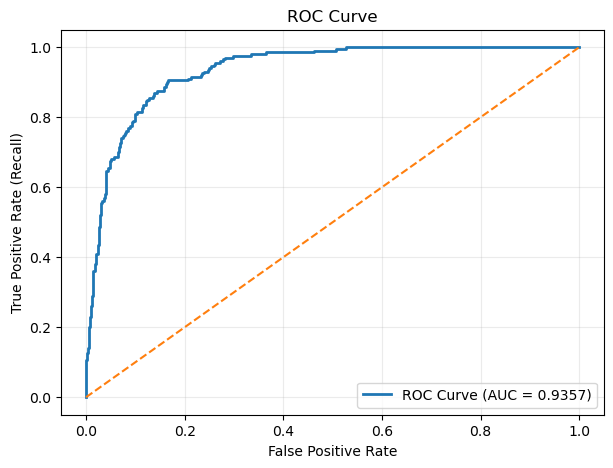

ROC AUC: 0.9357


In [4]:
# Cell 4: ROC Curve + AUC
# =========================================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

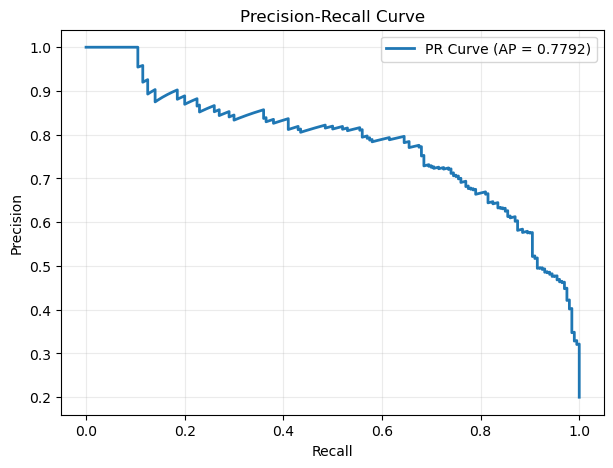

Average Precision (AP): 0.7792


In [5]:
# Cell 5: PR Curve + Average Precision
# =========================================
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR Curve (AP = {ap:.4f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Average Precision (AP): {ap:.4f}")

In [6]:
# Cell 6: Threshold metrics table
# =========================================
def evaluate_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    
    # FIX: Added labels=[0, 1] to prevent ValueError when a threshold classifies everything into a single class
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision_v = precision_score(y_true, y_pred, zero_division=0)
    recall_v = recall_score(y_true, y_pred, zero_division=0)
    f1_v = f1_score(y_true, y_pred, zero_division=0)
    acc_v = accuracy_score(y_true, y_pred)

    return {
        "threshold": threshold,
        "accuracy": acc_v,
        "precision": precision_v,
        "recall": recall_v,
        "f1": f1_v,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
rows = [evaluate_at_threshold(y_test, y_proba, t) for t in threshold_grid]
metrics_df = pd.DataFrame(rows)

print("Top 5 by F1 Score (Balanced):")
display(metrics_df.sort_values("f1", ascending=False).head(5))

print("\nTop 5 by Recall (Safety First):")
display(metrics_df.sort_values("recall", ascending=False).head(5))

Top 5 by F1 Score (Balanced):


,threshold,accuracy,precision,recall,f1,tp,fp,tn,fn
49,0.54,0.882,0.669421,0.810,0.733032,162,80,720,38
48,0.53,0.881,0.666667,0.810,0.731377,162,81,719,38
47,0.52,0.880,0.662602,0.815,0.730942,163,83,717,37
68,0.73,0.891,0.721951,0.740,0.730864,148,57,743,52
67,0.72,0.891,0.721951,0.740,0.730864,148,57,743,52



Top 5 by Recall (Safety First):


,threshold,accuracy,precision,recall,f1,tp,fp,tn,fn
0,0.05,0.668,0.374525,0.985,0.542700,197,329,471,3
1,0.06,0.696,0.395582,0.985,0.564470,197,301,499,3
2,0.07,0.728,0.422414,0.980,0.590361,196,268,532,4
3,0.08,0.745,0.438202,0.975,0.604651,195,250,550,5
4,0.09,0.763,0.456471,0.970,0.620800,194,231,569,6


In [7]:
# Cell 7: Pick best thresholds for different goals
# =========================================
# 1) Best F1 (Statistical balance)
best_f1_row = metrics_df.loc[metrics_df["f1"].idxmax()]

# 2) Safety-first threshold
# Goal: Maximize recall (catch all risks) but keep False Positive Rate acceptable.
# We ensure Precision is at least 0.40 so we don't spam the user with false alarms.
candidate = metrics_df[metrics_df["precision"] >= 0.40]

if len(candidate) > 0:
    safety_row = candidate.loc[candidate["recall"].idxmax()]
else:
    # Fallback if 0.40 precision isn't achievable
    safety_row = metrics_df.loc[metrics_df["recall"].idxmax()]

print("--- Best F1 Threshold (Statistical) ---")
print(best_f1_row.to_string())

print("\n--- Safety-First Threshold (Product Choice) ---")
print("Optimized for catching risks without rendering the map totally 'unsafe'")
print(safety_row.to_string())

--- Best F1 Threshold (Statistical) ---
threshold      0.540000
accuracy       0.882000
precision      0.669421
recall         0.810000
f1             0.733032
tp           162.000000
fp            80.000000
tn           720.000000
fn            38.000000

--- Safety-First Threshold (Product Choice) ---
Optimized for catching risks without rendering the map totally 'unsafe'
threshold      0.070000
accuracy       0.728000
precision      0.422414
recall         0.980000
f1             0.590361
tp           196.000000
fp           268.000000
tn           532.000000
fn             4.000000


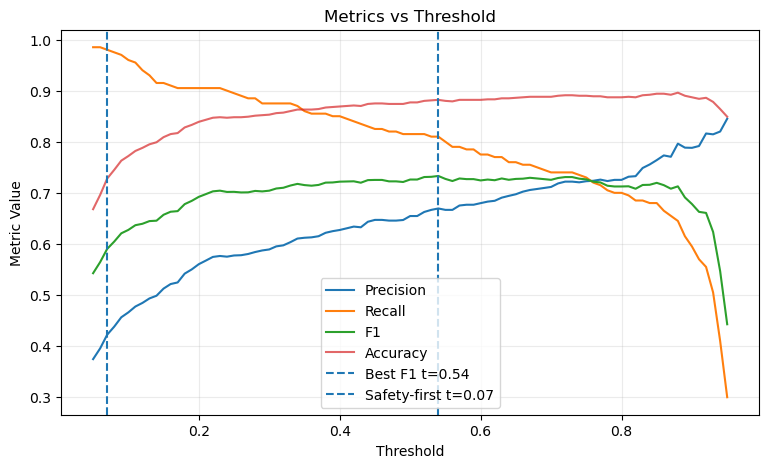

In [8]:
# Cell 8: Visualize threshold tradeoffs
# =========================================
plt.figure(figsize=(9, 5))
plt.plot(metrics_df["threshold"], metrics_df["precision"], label="Precision")
plt.plot(metrics_df["threshold"], metrics_df["recall"], label="Recall")
plt.plot(metrics_df["threshold"], metrics_df["f1"], label="F1")
plt.plot(metrics_df["threshold"], metrics_df["accuracy"], label="Accuracy", alpha=0.7)

plt.axvline(best_f1_row["threshold"], linestyle="--", linewidth=1.5, label=f'Best F1 t={best_f1_row["threshold"]:.2f}')
plt.axvline(safety_row["threshold"], linestyle="--", linewidth=1.5, label=f'Safety-first t={safety_row["threshold"]:.2f}')

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Metrics vs Threshold")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [9]:
# Cell 9: Save selected threshold config
# =========================================
threshold_config = {
    "best_f1_threshold": float(best_f1_row["threshold"]),
    "safety_first_threshold": float(safety_row["threshold"]),
    "roc_auc": float(roc_auc),
    "average_precision": float(ap)
}

joblib.dump(threshold_config, f"{ARTIFACTS_DIR}/threshold_config.joblib")
print("Saved threshold config to:", f"{ARTIFACTS_DIR}/threshold_config.joblib")
print(threshold_config)

Saved threshold config to: artifacts/threshold_config.joblib
{'best_f1_threshold': 0.54, 'safety_first_threshold': 0.07, 'roc_auc': 0.935725, 'average_precision': 0.7792139275525689}


In [10]:
# Cell 10: FastAPI-ready helper functions
# =========================================
def compute_risk_multiplier(probability: float, min_mult: float = 0.7, max_mult: float = 1.3) -> float:
    return float(min_mult + (max_mult - min_mult) * probability)

def predict_with_custom_threshold(input_features: dict, model_pipeline, feature_columns, threshold: float):
    x = pd.DataFrame([input_features], columns=feature_columns)
    prob = float(model_pipeline.predict_proba(x)[0, 1])
    pred = int(prob >= threshold)

    return {
        "risk_probability": round(prob, 6),
        "risk_multiplier": round(compute_risk_multiplier(prob), 6),
        "risk_label": pred,
        "threshold_used": float(threshold)
    }

# Example usage
cfg = joblib.load(f"{ARTIFACTS_DIR}/threshold_config.joblib")
threshold = cfg["safety_first_threshold"]  # choose based on product policy

sample_input = {
    "crime_density": 0.83,
    "crime_trend": 0.35,
    "crime_type_violence_ratio": 0.65,
    "transit_lines_nearby": 1,
    "transit_frequency": 5,
    "street_connectivity": 0.28,
    "avg_lighting_quality": 30,
    "crowd_density": 18,
    "weather_visibility": 3.8,
    "hour_of_day": 23,
    "day_of_week": 6,
    "is_holiday": 0,
    "route_length_km": 4.1,
    "num_intersections": 9
}

result = predict_with_custom_threshold(
    sample_input, model, feature_columns, threshold
)
print("Prediction with custom threshold:", result)

Prediction with custom threshold: {'risk_probability': 0.959765, 'risk_multiplier': 1.275859, 'risk_label': 1, 'threshold_used': 0.07}
